In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import joblib
import glob
import os
from scipy import stats

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
phiKK_ratio = 1
tritrig_ratio = 14515
wab_ratio = 3247

In [3]:
# Load MC data
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_TC_tritrig_limited.pk')
df_tritrig['PhiKK'] = 0.0
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_TC_phiKK_limited.pk')
df_phiKK['PhiKK'] = 1.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_TC_wab_limited.pk')
df_wab['PhiKK'] = 0.0 # Add label

# Make MC test set
# MUST BE CONSISTENT with BDT.ipynb and ANN.ipynb to avoid data leaks!!
tritrig_test = df_tritrig[20000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[3000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[3000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
Y_test = df_test['PhiKK']



/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_24322/3334288449.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_24322/3334288449.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_24322/3334288449.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [4]:
# Load trained models

ANN = mytools.Classifier(in_features=X_test.shape[1]).to(device)
ANN.load_state_dict(torch.load("/Users/mghrear/data/ML_data/patch/classifier_adv_2021_v9_pass5_TC_run"+str(1)+".pt", map_location=device))
ANN.eval() 

BDT = joblib.load('/Users/mghrear/data/ML_data/patch/BDT_2021_v9_pass5_TC_model.pkl')


In [5]:
# Get model predections
test_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy().astype(np.float32)) )
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


ANN_pred = mytools.test_final(test_loader, ANN, device)
ANN_pred=torch.sigmoid(torch.tensor(ANN_pred)).numpy()


BDT_pred = BDT.predict_proba(X_test)[:,1]

# Add predictions to dataframe 
df_test['ANN'] = ANN_pred
df_test['BDT'] = BDT_pred

# Add invariant mass to dataframe
df_test['InvM'] = mytools.get_InvM(df_test)


In [6]:
full_data_dir = '/Users/mghrear/data/HPS_data/2021_v9_pass5_TC_processed'
pk_files = glob.glob(os.path.join(full_data_dir, '*.pk'))

feature_cols = X_test.columns
qual_cols = ['pos_E_Ecal', 'pos_Px', 'ele_Ecal_z', 'ele_Ecal_y']

results = []
for i, f in enumerate(pk_files):
    print(f'[{i+1}/{len(pk_files)}] {os.path.basename(f)}', end='\r')
    chunk = pd.read_pickle(f)
    X_chunk = chunk[feature_cols]

    chunk_dataset = TensorDataset(torch.from_numpy(X_chunk.to_numpy().astype(np.float32)))
    chunk_loader = DataLoader(chunk_dataset, batch_size=1000, shuffle=False)
    ann_pred = torch.sigmoid(torch.tensor(mytools.test_final(chunk_loader, ANN, device))).numpy()


    out = chunk[qual_cols].copy()
    out['ANN'] = ann_pred
    out['InvM'] = mytools.get_InvM(chunk)
    results.append(out)


print(f'Done. Processed {len(pk_files)} files.')
df_data = pd.concat(results, ignore_index=True)

Done. Processed 712 files.9_job488.pk


In [7]:
# Split into tritrig, wab, background and phiKK dataframes
test_df_tritrig = df_test[df_test['type']=="tritrig"].reset_index(drop=True)
test_df_phiKK = df_test[df_test['type']=="phiKK"].reset_index(drop=True)
test_df_wab = df_test[df_test['type']=="wab"].reset_index(drop=True)
test_df_bkg = pd.concat([test_df_tritrig,test_df_wab])

# Combine dfs according to expected proportions 
k = min(len(test_df_tritrig) // tritrig_ratio, len(test_df_wab) // wab_ratio, len(test_df_phiKK) // phiKK_ratio)
n_tritrig, n_wab, n_phiKK = tritrig_ratio * k, wab_ratio * k, phiKK_ratio * k
print(f"k={k}  tritrig={n_tritrig}  wab={n_wab}  phiKK={n_phiKK}  total={n_tritrig+n_wab+n_phiKK}")

df_test_combined = pd.concat(
    [test_df_tritrig.iloc[:n_tritrig], test_df_wab.iloc[:n_wab], test_df_phiKK.iloc[:n_phiKK]],
    ignore_index=True, sort=False
)

k=13  tritrig=188695  wab=42211  phiKK=13  total=230919


In [8]:

ANN_selection = np.percentile(test_df_bkg['ANN'], 99.0)
BDT_selection = np.percentile(test_df_bkg['BDT'], 99.0)

# Apply ANN to data

chi2/ndf = 23523.6/99 = 237.612,  p = 0.000e+00


Text(0.02, 0.95, '$\\chi^2$/ndf = 237.612,  p = 0.000e+00')

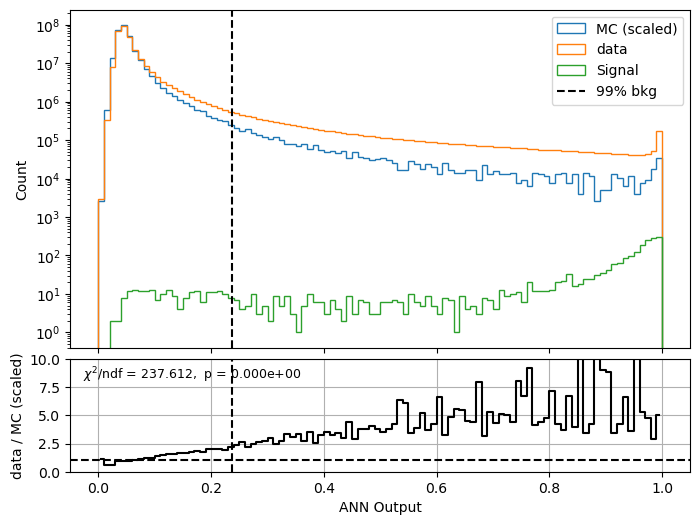

In [9]:
bins = np.arange(0,1.01,0.01)

mc   = df_test_combined['ANN'].to_numpy()
data = df_data['ANN'].to_numpy()
sig = test_df_phiKK['ANN'].to_numpy()


# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

mc_scale = data_counts.sum() / mc_counts.sum()

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts * mc_scale,
                  out=np.full_like(data_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

# Chi-squared test (only bins where mc_counts > 0)
mask = mc_counts > 0
chi2_vals = (data_counts[mask] - mc_counts[mask] * mc_scale)**2 / (data_counts[mask] + mc_scale**2 * mc_counts[mask])
chi2  = chi2_vals.sum()
ndf   = mask.sum() - 1  # -1 for normalization constraint
pval  = stats.chi2.sf(chi2, ndf)
print(f"chi2/ndf = {chi2:.1f}/{ndf} = {chi2/ndf:.3f},  p = {pval:.3e}")

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: MC scaled to match data total events ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, weights=np.full(len(mc), mc_scale), label='MC (scaled)')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(sig, bins=bins, histtype='step', label='Signal')

ax_top.set_ylabel('Count')
ax_top.set_yscale('log')
ax_top.axvline(x=ANN_selection, color='k', linestyle='--', label ="99% bkg")
ax_top.legend()

# --- Bottom: data / scaled MC ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.grid(True)
ax_bot.set_ylabel('data / MC (scaled)')
ax_bot.set_xlabel('ANN Output')
ax_bot.axhline(y=1, color='k', linestyle='--')
ax_bot.set_ylim(0, 10)
ax_bot.axvline(x=ANN_selection, color='k', linestyle='--', label ="selection line")
ax_bot.text(0.02, 0.95, f'$\\chi^2$/ndf = {chi2/ndf:.3f},  p = {pval:.3e}',
            transform=ax_bot.transAxes, fontsize=9, va='top')

In [10]:
QualCuts = {
    'pos_E_Ecal_low': 0.6,
    'pos_Px_low': -0.06,
    'ele_Ecal_z_low': 1448.6,
    'ele_Ecal_y_low': -85.0,
    'ele_Ecal_y_high': 85.0,
}

Text(0, 0.5, 'Count')

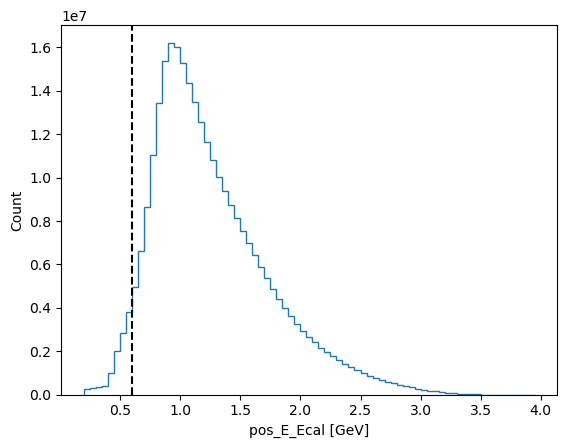

In [11]:
plt.hist(df_data.pos_E_Ecal, bins = np.arange(.2,4,0.05),histtype='step')
plt.axvline(x=QualCuts['pos_E_Ecal_low'], color='k', linestyle='--', label ="selection line")
plt.xlabel('pos_E_Ecal [GeV]')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

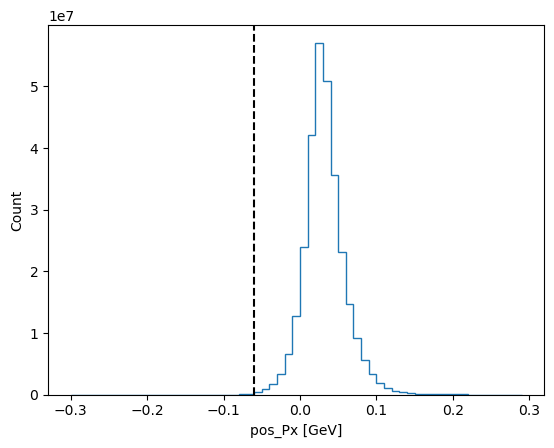

In [12]:
plt.hist(df_data.pos_Px, bins = np.arange(-.3,.3,0.01),histtype='step')
plt.axvline(x=QualCuts['pos_Px_low'], color='k', linestyle='--', label ="selection line")
plt.xlabel('pos_Px [GeV]')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

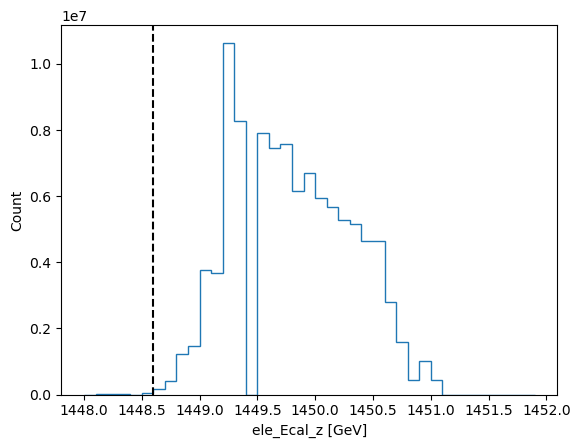

In [13]:
plt.hist(df_data.ele_Ecal_z, bins = np.arange(1448,1452,.1),histtype='step')
plt.axvline(x=QualCuts['ele_Ecal_z_low'], color='k', linestyle='--', label ="selection line")
plt.xlabel('ele_Ecal_z [GeV]')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

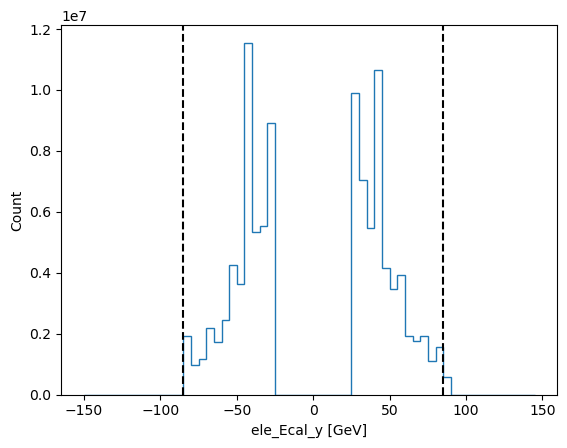

In [14]:
plt.hist(df_data.ele_Ecal_y, bins = np.arange(-150,150,5),histtype='step')
plt.axvline(x=QualCuts['ele_Ecal_y_low'], color='k', linestyle='--', label ="selection line")
plt.axvline(x=QualCuts['ele_Ecal_y_high'], color='k', linestyle='--')
plt.xlabel('ele_Ecal_y [GeV]')
plt.ylabel('Count')

In [15]:
df_data_Qual = df_data[
    (df_data.pos_E_Ecal > QualCuts['pos_E_Ecal_low']) &
    (df_data.pos_Px > QualCuts['pos_Px_low']) &
    ( (df_data.ele_Ecal_z > QualCuts['ele_Ecal_z_low']) | (df_data['ele_Ecal_z'] < 0)) &
    (df_data.ele_Ecal_y > QualCuts['ele_Ecal_y_low']) &
    (df_data.ele_Ecal_y < QualCuts['ele_Ecal_y_high'])
]

df_test_combined_Qual = df_test_combined[
    (df_test_combined.pos_E_Ecal > QualCuts['pos_E_Ecal_low']) &
    (df_test_combined.pos_Px > QualCuts['pos_Px_low']) &
    ( (df_test_combined.ele_Ecal_z > QualCuts['ele_Ecal_z_low']) | (df_test_combined['ele_Ecal_z'] < 0)) &
    (df_test_combined.ele_Ecal_y > QualCuts['ele_Ecal_y_low']) &
    (df_test_combined.ele_Ecal_y < QualCuts['ele_Ecal_y_high'])
]

chi2/ndf = 10561.2/98 = 107.768,  p = 0.000e+00


/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_24322/4179217782.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


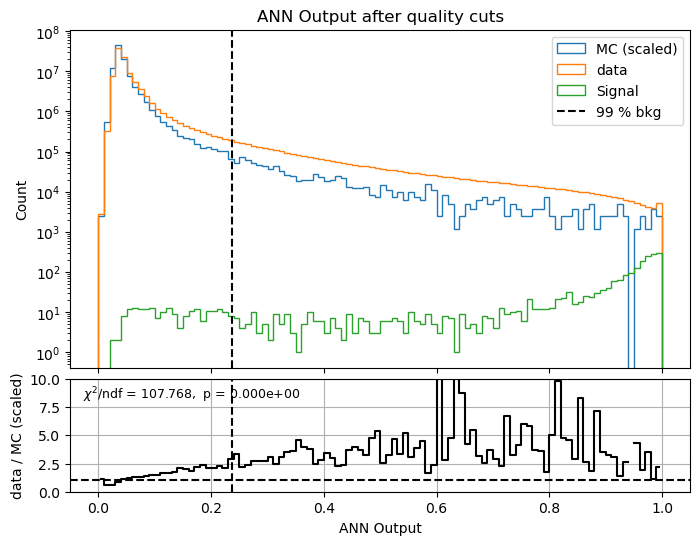

In [16]:
bins = np.arange(0, 1.01, 0.01)

mc_ann_cut   = df_test_combined_Qual['ANN'].to_numpy()
data_ann_cut = df_data_Qual['ANN'].to_numpy()
sig = test_df_phiKK['ANN'].to_numpy()


mc_counts,   edges = np.histogram(mc_ann_cut,   bins=bins)
data_counts, _     = np.histogram(data_ann_cut, bins=bins)

mc_scale = data_counts.sum() / mc_counts.sum()

centers = 0.5 * (edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts * mc_scale,
                  out=np.full_like(data_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

# Chi-squared test (only bins where mc_counts > 0)
mask = mc_counts > 0
chi2_vals = (data_counts[mask] - mc_counts[mask] * mc_scale)**2 / (data_counts[mask] + mc_scale**2 * mc_counts[mask])
chi2  = chi2_vals.sum()
ndf   = mask.sum() - 1  # -1 for normalization constraint
pval  = stats.chi2.sf(chi2, ndf)
print(f"chi2/ndf = {chi2:.1f}/{ndf} = {chi2/ndf:.3f},  p = {pval:.3e}")

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

ax_top.hist(mc_ann_cut,   bins=bins, histtype='step', density=False, weights=np.full(len(mc_ann_cut), mc_scale), label='MC (scaled)')
ax_top.hist(data_ann_cut, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(sig, bins=bins, histtype='step', label='Signal')
ax_top.set_ylabel('Count')
ax_top.set_yscale('log')
ax_top.axvline(x=ANN_selection, color='k', linestyle='--', label='99 % bkg')
ax_top.set_title('ANN Output after quality cuts')
ax_top.legend()

ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.axhline(y=1, color='k', linestyle='--')
ax_bot.grid(True)
ax_bot.set_ylabel('data / MC (scaled)')
ax_bot.axvline(x=ANN_selection, color='k', linestyle='--', label='selection line')
ax_bot.set_xlabel('ANN Output')
ax_bot.set_ylim(0, 10)
ax_bot.text(0.02, 0.95, f'$\\chi^2$/ndf = {chi2/ndf:.3f},  p = {pval:.3e}',
            transform=ax_bot.transAxes, fontsize=9, va='top')

plt.tight_layout()

In [20]:
ANN_selection = np.percentile(test_df_bkg['ANN'], 99.9)


In [21]:
ANN_selection

np.float64(0.6985111140000486)

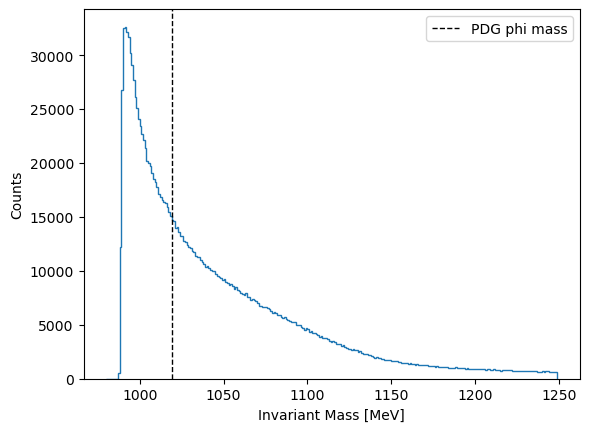

In [22]:
df_data_cut = df_data[df_data['ANN']>ANN_selection].reset_index(drop=True)
x_vals = 1000*df_data_cut.InvM


plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

Signal yield : 1747.0 ± 0.0
Mean         : 1020.037 ± 11.502 MeV
Sigma        : 0.115 ± 3.071 MeV
χ²/ndf       : 114.9 / 31 = 3.71  (p = 0.000)


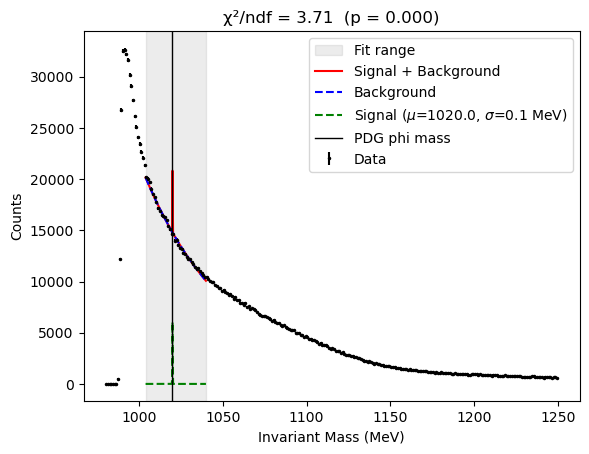

In [23]:
from scipy.optimize import curve_fit
x_vals = 1000*df_data_cut.InvM


m_phi = 1019.461
m_lo, m_hi = (1004, 1040)
bin_width = 1            # MeV per bin

bins = np.arange(m_lo, m_hi + bin_width, bin_width)
counts, edges = np.histogram(x_vals, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])
errors = np.where(counts > 0, np.sqrt(counts), 1)  # Poisson errors, floor at 1

def signal(m, n_sig, mu, sigma):
    return n_sig / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((m - mu) / sigma) ** 2)

def background(m, n_bkg, lam):
    return n_bkg * lam * np.exp(-lam * (m - m_lo))

def model(m, n_sig, mu, sigma, n_bkg, lam):
    return signal(m, n_sig, mu, sigma) + background(m, n_bkg, lam)

p0     = [1000,  m_phi, 5,   counts.sum(), 1/30]
bounds = ([0,    1000,  0.1, 0,            0   ],
          [np.inf, 1060, 50, np.inf,       1   ])

popt, pcov = curve_fit(model, centers, counts, p0=p0, sigma=errors,
                       absolute_sigma=True, bounds=bounds)
perr = np.sqrt(np.diag(pcov))
n_sig, mu, sigma, n_bkg, lam = popt
n_sig_err, mu_err, sigma_err = perr[:3]

chi2 = np.sum(((counts - model(centers, *popt)) / errors) ** 2)
ndf  = len(counts) - len(popt)
from scipy.stats import chi2 as chi2_dist
pval = chi2_dist.sf(chi2, ndf)
print(f"Signal yield : {n_sig:.1f} ± {n_sig_err:.1f}")
print(f"Mean         : {mu:.3f} ± {mu_err:.3f} MeV")
print(f"Sigma        : {sigma:.3f} ± {sigma_err:.3f} MeV")
print(f"χ²/ndf       : {chi2:.1f} / {ndf} = {chi2/ndf:.2f}  (p = {pval:.3f})")

# Full-range histogram
full_bins = np.arange(980, 1251, bin_width)
full_counts, full_edges = np.histogram(x_vals, bins=full_bins)
full_centers = 0.5 * (full_edges[:-1] + full_edges[1:])
full_errors = np.where(full_counts > 0, np.sqrt(full_counts), 1)

m_fine = np.linspace(m_lo, m_hi, 1000)
fig, ax = plt.subplots()
ax.errorbar(full_centers, full_counts, yerr=full_errors, fmt='k.', ms=3, label='Data')
ax.axvspan(m_lo, m_hi, color='grey', alpha=0.15, label='Fit range')
ax.plot(m_fine, model(m_fine, *popt),             'r-',  label='Signal + Background')
ax.plot(m_fine, background(m_fine, n_bkg, lam),   'b--', label='Background')
ax.plot(m_fine, signal(m_fine, n_sig, mu, sigma),  'g--', label=f'Signal ($\\mu$={mu:.1f}, $\\sigma$={sigma:.1f} MeV)')
ax.axvline(m_phi, color='k', linewidth=1, label='PDG phi mass')
ax.set_title(f'χ²/ndf = {chi2/ndf:.2f}  (p = {pval:.3f})')
ax.set_xlabel('Invariant Mass (MeV)')
ax.set_ylabel('Counts')
ax.legend()
plt.show()

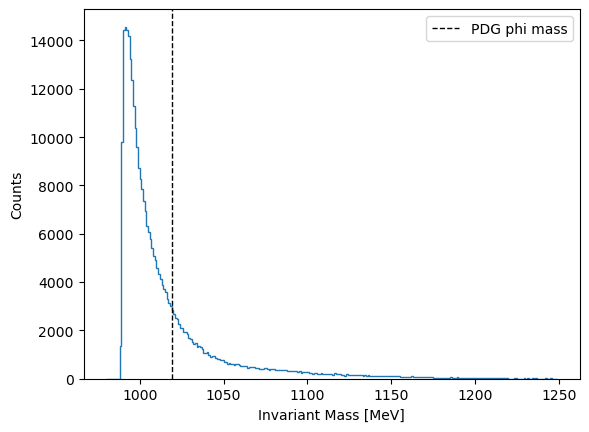

In [24]:
df_data_Qual_cut = df_data_Qual[df_data_Qual['ANN']>ANN_selection].reset_index(drop=True)
x_vals = 1000*df_data_Qual_cut.InvM


plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()

In [ ]:
#df_data_cut.InvM.to_csv('/Users/mghrear/Desktop/Emrys_phiKK/data_2021_ANN_M.csv', index=False)

In [ ]:
#df_data_cut = df_data[df_data['ANN']>ANN_selection].reset_index(drop=True)
#df_data_cut.InvM.to_csv('/Users/mghrear/Desktop/Emrys_phiKK/data_2021_ANN_bump_M.csv', index=False)